# Commodity Volatility & Macro Model

Modeling WTI crude oil volatility and testing which macro factors actually move crude returns.

The question driving this: the dollar-oil relationship is one of the most frequently repeated claims in commodities. Does it hold up?

**Spoiler:** on the full sample it looks like it doesn't. That turns out to be wrong, and the reason why is the interesting part.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from arch import arch_model

from commodity_vol_macro import (
    download_prices, to_log_returns, fit_garch, annualized_vol,
    vol_persistence, half_life, macro_regression,
    fit_markov_regimes, regime_regressions,
    TARGET, FACTORS,
)

# the analysis module forces the Agg backend on import; re-enable inline plotting
%matplotlib inline

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 1. Data

WTI front-month futures plus six macro factors, from Yahoo Finance. Log returns in percent.

In [2]:
prices = download_prices()
returns = to_log_returns(prices)

print(f"{len(returns):,} trading days | {returns.index.min():%Y-%m-%d} to {returns.index.max():%Y-%m-%d}")
returns.tail()

4,166 trading days | 2010-01-05 to 2026-07-23


Ticker,CL=F,DX-Y.NYB,GC=F,HG=F,^GSPC,^TNX,^VIX
Date,,,,,,,
2026-07-17,4.386,0.020,0.678,-1.214,-1.015,-0.615,11.506
2026-07-20,0.893,0.238,-0.060,1.262,-0.193,1.247,-0.641
2026-07-21,1.998,0.188,1.505,3.310,0.882,0.650,-8.970
2026-07-22,2.236,-0.040,1.845,-0.926,-0.136,0.625,-2.434
2026-07-23,6.488,0.303,-2.362,-1.901,-1.315,0.898,14.518


In [3]:
returns.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Ticker,,,,
CL=F,0.018,2.614,-28.221,31.963
DX-Y.NYB,0.006,0.444,-2.399,2.032
GC=F,0.031,1.079,-12.066,5.905
HG=F,0.016,1.526,-25.171,12.444
^GSPC,0.046,1.085,-12.765,9.089
^TNX,0.008,2.716,-34.701,40.480
^VIX,-0.005,7.814,-44.245,76.825


Note the kurtosis before assuming normality anywhere:

In [4]:
returns[TARGET].kurtosis()

np.float64(22.23853334598025)

~28. Enormously fat-tailed. Any model here needs Student-t errors, not Gaussian.

## 2. Volatility: GARCH(1,1)

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Today's variance depends on yesterday's shock and yesterday's variance — which is how volatility clustering gets modeled.

In [5]:
garch = fit_garch(returns[TARGET])
print(garch.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         CL=F   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8882.17
Distribution:      Standardized Student's t   AIC:                           17774.3
Method:                  Maximum Likelihood   BIC:                           17806.0
                                              No. Observations:                 4166
Date:                      Thu, Jul 23 2026   Df Residuals:                     4165
Time:                              17:45:07   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [6]:
ann_vol = annualized_vol(garch)
persist = vol_persistence(garch)

print(f"Persistence (alpha+beta): {persist:.4f}")
print(f"Shock half-life:          {half_life(persist):.1f} trading days")
print(f"Mean annualized vol:      {ann_vol.mean():.1f}%")
print(f"Latest annualized vol:    {ann_vol.iloc[-1]:.1f}%")

Persistence (alpha+beta): 0.9861
Shock half-life:          49.6 trading days
Mean annualized vol:      36.1%
Latest annualized vol:    47.2%


Persistence of 0.986 sits just below the non-stationary boundary. A volatility shock decays halfway back to its long-run level only after ~50 trading days — about ten weeks. This is why oil shocks show up as plateaus, not spikes.

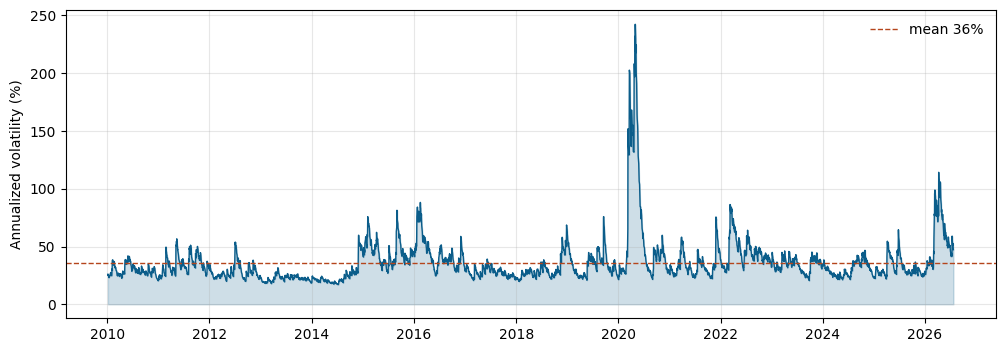

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(ann_vol.index, ann_vol.values, alpha=0.2, color="#0b5d8a")
ax.plot(ann_vol.index, ann_vol.values, color="#0b5d8a", lw=1)
ax.axhline(ann_vol.mean(), color="#b5451c", ls="--", lw=1, label=f"mean {ann_vol.mean():.0f}%")
ax.set_ylabel("Annualized volatility (%)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

## 3. The naive regression

Regress crude returns on contemporaneous macro factors. HAC (Newey-West) standard errors, since daily financial data has both autocorrelation and heteroskedasticity.

In [8]:
fit = macro_regression(returns)
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   CL=F   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     31.85
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.15e-37
Time:                        17:45:07   Log-Likelihood:                -9648.5
No. Observations:                4166   AIC:                         1.931e+04
Df Residuals:                    4159   BIC:                         1.936e+04
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0104      0

In [9]:
pd.DataFrame({
    "beta": fit.params.drop("const"),
    "p_value": fit.pvalues.drop("const"),
}).sort_values("p_value")

,beta,p_value
Copper,0.292,0.000
S&P 500,0.370,0.002
Gold,0.174,0.009
10Y Treasury Yield,0.142,0.023
US Dollar Index,-0.049,0.729
VIX,0.003,0.811


**The dollar coefficient is −0.05 with p = 0.73.** Statistically indistinguishable from zero.

Read literally, that says the dollar doesn't move oil — which contradicts both theory (oil is priced in dollars) and essentially every trading desk's stated view.

Before accepting a null result that surprising, it's worth asking whether the sample is hiding something.

## 4. Estimating regimes

A common fix is to split the sample at median volatility. That's arbitrary: it forces exactly half the days into each bucket and puts the boundary wherever the median happens to fall.

Better to let the data decide. A two-state Markov-switching model with regime-dependent variance:

$$r_t \mid S_t = s \;\sim\; N(\mu_s,\, \sigma_s^2), \qquad S_t \in \{\text{calm}, \text{crisis}\}$$

with transition probabilities estimated alongside the state parameters.

In [10]:
ms, crisis, crisis_idx = fit_markov_regimes(returns[TARGET])
print(ms.summary())

                        Markov Switching Model Results                        
Dep. Variable:                   CL=F   No. Observations:                 4166
Model:               MarkovRegression   Log Likelihood               -9097.169
Date:                Thu, 23 Jul 2026   AIC                          18206.338
Time:                        17:45:08   BIC                          18244.346
Sample:                             0   HQIC                         18219.783
                               - 4166                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0429      0.030      1.413      0.158      -0.017       0.102
sigma2         2.9015      0.098     29.524      0.0

In [11]:
calm_idx = 1 - crisis_idx
for label, idx in [("Calm", calm_idx), ("Crisis", crisis_idx)]:
    vol = np.sqrt(ms.params[f"sigma2[{idx}]"]) * np.sqrt(252)
    print(f"{label:7s} annualized vol {vol:5.1f}%  |  expected duration {ms.expected_durations[idx]:.0f} days")

print(f"\nCrisis days: {int(crisis.sum()):,} ({100*crisis.mean():.1f}% of sample)")

Calm    annualized vol  27.0%  |  expected duration 75 days
Crisis  annualized vol  82.0%  |  expected duration 15 days

Crisis days: 657 (15.8% of sample)


Roughly 9x the variance in the crisis state. Now — did it find anything real, or just fit noise? Check which periods it flagged:

In [12]:
flag = crisis.astype(int).values
edges = np.diff(np.concatenate([[0], flag, [0]]))
starts, ends = np.where(edges == 1)[0], np.where(edges == -1)[0] - 1

episodes = pd.DataFrame({
    "start": crisis.index[starts],
    "end": crisis.index[ends],
    "days": ends - starts + 1,
}).sort_values("days", ascending=False)

episodes.head(8).reset_index(drop=True)

,start,end,days
0,2015-12-02,2016-04-12,91
1,2026-02-27,2026-06-26,84
2,2020-02-24,2020-06-16,78
3,2014-11-28,2015-02-27,62
4,2022-02-28,2022-05-16,55
5,2018-11-13,2018-12-27,30
6,2022-06-16,2022-07-25,26
7,2015-08-19,2015-09-22,24


The model was never told what a crisis is, and it recovered: the 2015–16 oil collapse, COVID, the November 2014 OPEC decision, the 2022 Ukraine invasion — plus a regime that began in late February 2026 and is still running.

That's the validation. These are the episodes an energy trader would list from memory.

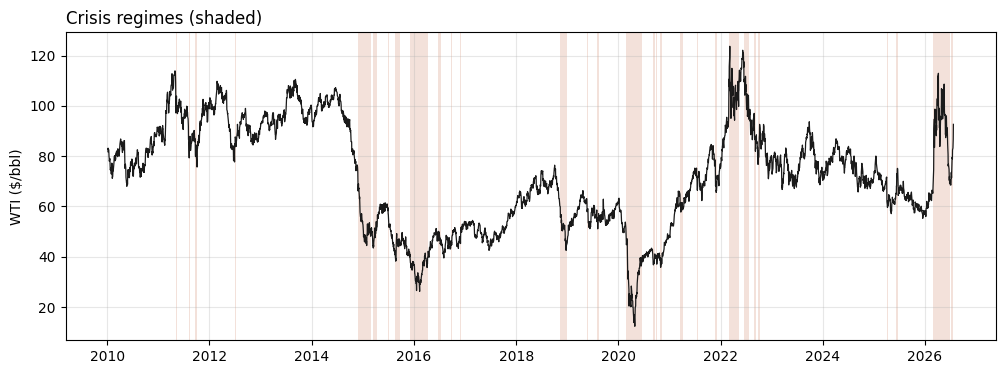

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
px = prices[TARGET].loc[crisis.index]
ax.plot(px.index, px.values, color="#1a1a1a", lw=0.9, zorder=3)
for s, e in zip(starts, ends):
    ax.axvspan(crisis.index[s], crisis.index[e], color="#b5451c", alpha=0.16, lw=0)
ax.set_ylabel("WTI ($/bbl)")
ax.set_title("Crisis regimes (shaded)", loc="left")
ax.grid(alpha=0.3)
plt.show()

## 5. The same factors, two different markets

Re-estimate the macro betas within each regime.

In [14]:
regimes = regime_regressions(returns, crisis)

comparison = pd.DataFrame({
    f"{label} beta": r.params.drop("const") for label, r in regimes.items()
})
for label, r in regimes.items():
    comparison[f"{label} p"] = r.pvalues.drop("const")

comparison[["Calm regime beta", "Calm regime p", "Crisis regime beta", "Crisis regime p"]]

,Calm regime beta,Calm regime p,Crisis regime beta,Crisis regime p
US Dollar Index,-0.255,0.001,0.534,0.254
S&P 500,0.299,0.000,0.386,0.179
VIX,-0.001,0.930,0.013,0.762
Gold,0.175,0.000,0.125,0.548
10Y Treasury Yield,0.140,0.000,0.133,0.285
Copper,0.202,0.000,0.657,0.000


In [15]:
for label, r in regimes.items():
    print(f"{label:15s} adj. R^2 = {r.rsquared_adj:.3f}   (n = {int(r.nobs):,})")

Calm regime     adj. R^2 = 0.155   (n = 3,509)
Crisis regime   adj. R^2 = 0.108   (n = 657)


### What this shows

**The dollar effect is real and conditional.** In the calm regime the beta is **−0.26 with p = 0.001** — the textbook relationship, cleanly identified. In crisis it flips positive and goes insignificant. The pooled estimate of −0.05 wasn't measuring absence; it was averaging two opposite regimes into nothing.

**In a crisis, crude decouples from finance.** Equities, gold, rates, VIX — all significant in the calm state, none significant in the crisis state.

**Physical demand survives and strengthens.** Copper is the only factor significant in both, and its beta more than triples (+0.20 → +0.66). When oil is genuinely volatile, it trades on industrial demand, not financial risk appetite.

**And explanatory power falls** from 0.155 to 0.108 — this factor set explains least exactly when a risk model is needed most.

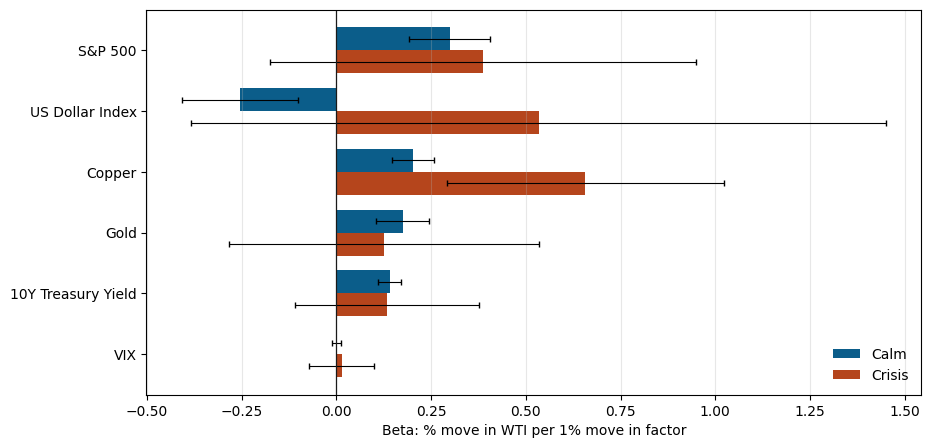

In [16]:
names = list(FACTORS.values())
order = sorted(names, key=lambda n: abs(regimes["Calm regime"].params[n]))
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y + 0.19, [regimes["Calm regime"].params[n] for n in order], height=0.38,
        xerr=[1.96 * regimes["Calm regime"].bse[n] for n in order],
        color="#0b5d8a", label="Calm", error_kw=dict(elinewidth=0.8, capsize=2.5))
ax.barh(y - 0.19, [regimes["Crisis regime"].params[n] for n in order], height=0.38,
        xerr=[1.96 * regimes["Crisis regime"].bse[n] for n in order],
        color="#b5451c", label="Crisis", error_kw=dict(elinewidth=0.8, capsize=2.5))
ax.axvline(0, color="#1a1a1a", lw=0.9)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel("Beta: % move in WTI per 1% move in factor")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.show()

## Limitations

- **Contemporaneous, not causal.** Every regressor is same-day. This decomposes comovement; it doesn't identify causation and isn't a forecast.
- **Smoothed probabilities condition on the full sample.** Fine for describing history — but a real-time system would need *filtered* probabilities, because the smoothed version effectively knows the future.
- **657 crisis observations across 36 episodes.** The wide crisis confidence intervals are honest about how little can be identified from stress periods.
- **Front-month futures carry roll effects.** A continuous back-adjusted series would be more rigorous.
- **Residual kurtosis of 27.8** means tail inference deserves caution even with HAC errors.

### Natural extensions

Filtered probabilities for a real-time regime signal; a DCC-GARCH to model the correlations themselves as time-varying rather than splitting the sample; and adding genuine supply-side variables (EIA inventories, rig counts, OPEC announcements) which are absent here and are plausibly what the crisis regime is actually responding to.